In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import WhiteKernel
#from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import norm
from scipy.stats import qmc
from scipy.spatial.distance import cdist
from sklearn.neural_network import MLPRegressor

In [7]:
#Function to add data points each week.
current_week = 14   # CHANGE THIS EACH WEEK



# =====================================================
# LOAD DATA
# =====================================================

if current_week == 1:

    X = np.load(r"function_8\initial_inputs.npy")
    Y = np.load(r"function_8\initial_outputs.npy")

else:

    previous_week = current_week - 1

    X = np.load(
        f"function_8/w{previous_week}_inputs.npy"
    )

    Y = np.load(
        f"function_8/w{previous_week}_outputs.npy"
    )


print("\nLoaded dataset:")
print("Shape:", X.shape)
print("Best Y so far:", np.max(Y))

dim = X.shape[1]


# =====================================================
# ENTER LAST WEEK RESULT
# (Skip this only in Week 1)
# =====================================================

if current_week > 1:

    print("\nEnter last week's result")

    x_string = input(
        "Enter last submitted X (format x1-x2): "
    )

    y_value = float(
        input("Enter returned Y value: ")
    )

    x_last = np.array(
        [[float(v) for v in x_string.split("-")]]
    )

    y_last = np.array([y_value])


    # Safe append

    exists = np.any(
        np.all(
            np.isclose(X, x_last),
            axis=1
        )
    )

    if not exists:

        X = np.vstack((X, x_last))
        Y = np.append(Y, y_last)

        print("Added last result.")

    else:

        print("Duplicate detected — skipped.")



Loaded dataset:
Shape: (52, 8)
Best Y so far: 9.9613449317905

Enter last week's result


Enter last submitted X (format x1-x2):  0.157656-0.105033-0.167022-0.181387-0.996728-0.551806-0.212348-0.434819
Enter returned Y value:  9.9611642739059


Added last result.


In [13]:
# =====================================================
# SAVE UPDATED DATA
# =====================================================


np.save(
    f"function_8/w{current_week}_inputs.npy",
    X
)

np.save(
    f"function_8/w{current_week}_outputs.npy",
    Y
)

print("\nSaved files:")

print(
    f"function_8/w{current_week}_inputs.npy"
)

print(
    f"function_8/w{current_week}_outputs.npy"
)


Saved files:
function_8/w14_inputs.npy
function_8/w14_outputs.npy


In [1]:
import numpy as np
from scipy.spatial.distance import cdist

X = np.load("function_8/w14_inputs.npy")
Y = np.load("function_8/w14_outputs.npy")

sorted_idx = np.argsort(Y)[::-1]
print("Top 8 points ranked best to worst:")
for i in sorted_idx[:8]:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  Y={Y[i]:.6f} | X={vals}")

print(f"\nTotal: {len(Y)}")
print(f"Best Y:  {np.max(Y):.6f}")

best_point = X[np.argmax(Y)]
distances  = cdist([best_point], X)[0]
sorted_by_dist = np.argsort(distances)

print("\nNearest neighbours to best point:")
for i in sorted_by_dist[:6]:
    vals = "-".join([f"{v:.6f}" for v in X[i]])
    print(f"  dist={distances[i]:.4f} | Y={Y[i]:.4f} | X={vals}")

print("\nKey dimensions in top 5:")
for i in sorted_idx[:5]:
    print(f"  Y={Y[i]:.6f} | "
          f"x1={X[i,0]:.6f} | x2={X[i,1]:.6f} | "
          f"x3={X[i,2]:.6f} | x4={X[i,3]:.6f} | "
          f"x5={X[i,4]:.6f} | x6={X[i,5]:.6f} | "
          f"x7={X[i,6]:.6f} | x8={X[i,7]:.6f}")

Top 8 points ranked best to worst:
  Y=9.961345 | X=0.155000-0.107498-0.166315-0.177791-0.999120-0.559435-0.207201-0.438465
  Y=9.961164 | X=0.157656-0.105033-0.167022-0.181387-0.996728-0.551806-0.212348-0.434819
  Y=9.959714 | X=0.155157-0.091613-0.164855-0.172562-0.996845-0.567473-0.207821-0.439063
  Y=9.894198 | X=0.192592-0.278370-0.150667-0.046318-0.986715-0.650942-0.274324-0.301964
  Y=9.879882 | X=0.193287-0.277659-0.147052-0.037248-0.987334-0.676266-0.287136-0.299527
  Y=9.874021 | X=0.195407-0.273737-0.143773-0.032776-0.989452-0.684133-0.293055-0.300282
  Y=9.863537 | X=0.155000-0.254835-0.141039-0.259795-0.998982-0.749758-0.090462-0.508929
  Y=9.858344 | X=0.291983-0.059662-0.223515-0.071276-0.994775-0.465633-0.143569-0.508986

Total: 53
Best Y:  9.961345

Nearest neighbours to best point:
  dist=0.0000 | Y=9.9613 | X=0.155000-0.107498-0.166315-0.177791-0.999120-0.559435-0.207201-0.438465
  dist=0.0114 | Y=9.9612 | X=0.157656-0.105033-0.167022-0.181387-0.996728-0.551806-0.212

## Function 8 — ML Hyperparameter Tuning (8D)

**Objective**: Maximise the output of a high-dimensional machine 
learning hyperparameter tuning function across eight continuous 
input dimensions.

---

### The Challenge — High Dimensionality and Limited Data

The F8 brief explicitly acknowledged that **global optimisation is 
hard** for an 8-dimensional function and that identifying strong 
local maxima is a practical and acceptable goal. With one query per 
week across 13 weeks, the dataset grew to just 52 observations — 
approximately **6 observations per dimension**. Standard guidance 
for reliable GP generalisation suggests 10-30 observations per 
dimension, meaning F8 was always operating in an under-sampled 
regime relative to its complexity.

This shaped every strategic decision for F8 — rather than attempting 
to map the global landscape, the goal was to find and systematically 
refine the strongest local maximum the data could reliably identify.

---

### Why Multiple Surrogates?

No single surrogate model is well-suited to all phases of 
optimisation in a high-dimensional, data-sparse setting. Five 
different approaches were used simultaneously each week, each 
contributing a different perspective on where the next query 
should land:

---

### The Five Surrogates

#### 1. Gaussian Process (GP)
The primary surrogate throughout the project. The GP builds a 
probabilistic model of the landscape — not just predicting Y values 
but also estimating its own uncertainty at each point. This 
uncertainty estimate is what makes GP particularly valuable: it 
allows the acquisition function (Expected Improvement) to balance 
going to known good spots versus exploring uncertain areas.

GP LOO RMSE improved consistently across the project, from 0.196 
in early weeks to **0.089 in week 13**  reflecting genuine 
improvement in landscape modelling as more observations accumulated. 
One persistent anomaly: **x8 consistently hit a length scale of 
1000**, meaning the GP learned to effectively ignore this dimension 
entirely — consistent with the brief's suggestion of encoded 
categorical variables where the GP's smoothness assumption breaks 
down.

```python
kernel = (
    C(1.0, (1e-3, 1e5))
    * RBF(length_scale=[0.1]*dim,
          length_scale_bounds=(1e-3, 10.0))
    + WhiteKernel(noise_level=1e-5,
                  noise_level_bounds=(1e-12, 1e-1))
)
```

---

#### 2. Random Forest (RF) with GridSearchCV Tuning

Random Forest was added as a non-parametric alternative to GP as
it makes no assumptions about the smoothness of the landscape and 
handles non-linear relationships naturally. Unlike GP, RF does not 
extrapolate beyond its training data, making it more conservative 
and less prone to suggesting implausible candidates in unexplored 
regions.

RF hyperparameters were tuned weekly using **GridSearchCV** — 
an exhaustive search across candidate parameter combinations 
evaluated by cross-validated mean squared error:

```python
param_grid = {
    'n_estimators':     [100, 200],
    'max_features':     [0.3, 0.5, 0.7],
    'min_samples_leaf': [1, 2, 5]
}
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5,
    scoring='neg_mean_squared_error'
)
```

**Why GridSearchCV?** With only 50 observations and 8 dimensions, 
RF's performance is highly sensitive to its hyperparameters — 
particularly `min_samples_leaf` (controlling overfitting) and 
`max_features` (controlling how many dimensions each tree considers). 
Rather than fixing these at arbitrary values, weekly retuning 
allowed RF to adapt as the dataset grew and the confirmed region 
narrowed.

RF LOO RMSE of approximately 0.49-0.51 throughout the project, 
consistently worse than GP's 0.089-0.141  meant RF rarely won 
model selection but provided a useful cross-check on GP's suggestions.

---

#### 3. RF-Quality Filter

A refinement on standard RF:rather than fitting on all 52 
observations, the RF-quality model fits only on the **top 
performing subset** of historical observations:

```python
# Only observations above the 60th percentile of Y
quality_threshold = np.percentile(Y, 60)
quality_mask      = Y >= quality_threshold
X_quality         = X[quality_mask]
Y_quality         = Y[quality_mask]
```

**Why this matters**: Standard RF fitted on all observations 
includes many poor early-exploration results that reflect the 
global landscape rather than the confirmed good region. By 
restricting to high-quality observations, RF-quality builds 
a surrogate specifically calibrated to the confirmed peak 
neighbourhood — more relevant for late-stage exploitation 
than a model trained on the full mixed history.

In practice RF-quality typically selected approximately 20-21 
observations from the full dataset of 52, concentrating the 
model on results above Y≈8.5.

---

#### 4. Neural Network (NN)

A simple feedforward neural network was included as a third 
alternative surrogate, trained using early stopping to prevent 
overfitting:

```python
from sklearn.neural_network import MLPRegressor
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    early_stopping=True,
    random_state=42
)
```

**Why it never performed well — and why this was anticipated**

Neural networks are data-hungry by nature. With 52 observations 
across 8 dimensions, the NN was always severely under-served. 
The brief's acknowledgement of high dimensionality and complexity 
suggested from the outset that a neural network would struggle — 
there simply were not enough data points for the network to learn 
meaningful patterns rather than fitting noise.

NN LOO RMSE ranged from **1.93 to 2.32** throughout the project — 
consistently 15-25x worse than GP and 4-5x worse than RF. The NN 
was excluded by the range validation check in every single week, 
suggesting it was consistently recommending points in regions with 
no empirical support. It was retained in the pipeline as a 
comparison point rather than a genuine candidate generator — 
useful for demonstrating why data volume matters for neural 
approaches, but never competitive in this setting.

---

#### 5. CMA-ES (Covariance Matrix Adaptation Evolution Strategy)

CMA-ES via Optuna was the most consistently effective candidate 
generator for F8 throughout the project. Unlike the surrogate 
models above, CMA-ES is an **evolutionary optimisation algorithm** 
rather than a statistical model — it does not build a landscape 
model but instead learns which directions in the search space 
tend to produce improvements and concentrates its search there.

```python
sigma0 = max(min_range / 6, 0.003)  # tight exploitation
cmaes_sampler = optuna.samplers.CmaEsSampler(
    x0     = best_point_dict,
    sigma0 = sigma0,
    seed   = 42
)
```

CMA-ES was the **only eligible candidate in the later weeks**. 
Previously the GP predictions were extremely close to the real
Y values.  RF, RF-quality, and NN were consistently excluded 
by the range validation check (suggesting coordinates outside the
confirmed good region), while CMA-ES anchored tightly to the confirmed best 
point and stayed within all eight confirmed dimension ranges.

The one deliberate exception was the **week 11 GP gamble**  
with GP LOO RMSE at its all-time best of 0.089, the GP's 
suggestion was submitted instead of CMA-ES. This returned 
Y=9.9613, a new best, and gave CMA-ES a stronger anchor 
point for the remaining weeks.

---

### How LOO Cross-Validation Ties It All Together

With five competing surrogates generating different suggestions 
each week, an objective selection criterion was essential. 
**Leave-One-Out (LOO) cross-validation** provided this: for 
each surrogate, every historical observation is temporarily 
removed, the model is retrained on the remainder, and the 
held-out observation is predicted. The Root Mean Squared Error 
across all held-out predictions measures how reliably the 
surrogate generalises to unseen data points.

The surrogate with the lowest LOO RMSE is designated **primary** 
and its suggestion takes priority in the final selection — subject 
to range validation and plausibility checks:

**Why LOO rather than standard train/test split?**

With only 52 observations, holding out a fixed test set would 
waste valuable training data and produce unstable estimates. 
LOO uses every observation as both training data and a test 
point in turn maximising the use of limited data while 
providing a reliable estimate of each model's true predictive 
accuracy.

LOO RMSE as a fraction of the Y range (approximately 9.9 units) 
provides the key interpretability check:

| Surrogate | LOO RMSE | % of Y range | Reliability |
|-----------|----------|-------------|-------------|
| GP | 0.089 | 0.9% | Excellent |
| RF | 0.492 | 5.0% | Moderate |
| NN | 2.173 | 21.9% | Poor |

GP's 0.9% error rate relative to the Y range means its 
predictions are trustworthy guides for distinguishing between 
good and poor candidates. NN's 21.9% means its predictions 
are too uncertain to act on — and this is exactly what the 
LOO selection criterion correctly identified and acted upon 
every week by never selecting the NN as primary.

---

### Final Result

| Metric | Value |
|--------|-------|
| Best Y achieved | 9.9613 |
| Week achieved | Week 11 (GP gamble) |
| Method | GP suggestion (week 11), CMA-ES exploitation (weeks 12-13) |
| GP LOO RMSE at finish | 0.089 |
| Dataset size at finish | 52 observations |
| x8 length scale | 1000 (categorical dimension — ignored by GP) |

The consistent improvement across 13 weeks — from early 
exploration returns below 1.0 to a final best of 9.9613 — 
reflects the brief's own framing: in high-dimensional complex 
functions, **finding and systematically refining a strong local 
maximum is a legitimate and valuable outcome**, even when the 
true global optimum remains unknown.

Running GridSearchCV for RF...
Best RF parameters:
  n_estimators:     200
  max_features:     0.5
  min_samples_leaf: 1
  CV score (neg MSE): -0.3452
NN trained for 78 iterations

All surrogates fitted
Best real point: [0.155    0.107498 0.166315 0.177791 0.99912  0.559435 0.207201 0.438465]
Best real Y:     9.961345

Fitted kernel length scales:
  x1: 2.1172
  x2: 3.0957
  x3: 1.5538
  x4: 3.2705
  x5: 11.2453
  x6: 2.6491
  x7: 2.0918
  x8: 1000.0000 ← hitting bound

=== LOO CROSS VALIDATION ===
GP  LOO RMSE: 0.0893
RF  LOO RMSE: 0.4924
NN  LOO RMSE: 2.1728
Primary surrogate: GP

RF quality filter: 21 points at Y >= 8.5804


C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\optuna\samplers\_cmaes.py:302: FutureWarning: `x0` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(msg, FutureWarning)
C:\Users\MAGS\anaconda3\envs\bbo_env\lib\site-packages\optuna\samplers\_cmaes.py:307: FutureWarning: `sigma0` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(msg, FutureWarning)



5 SURROGATE COMPARISON — Function 8

--- GP (LOO=0.089) ---
  Suggestion:         0.155000-0.252298-0.157596-0.138356-0.992172-0.306897-0.013800-0.265447
  GP predicted Y:     9.805640
  Distance from best: 0.392124
  x1=0.1550 x2=0.2523 x3=0.1576 x4=0.1384 x5=0.9922

--- RF (LOO=0.492) ---
  Suggestion:         0.155000-0.220742-0.269022-0.217839-0.999192-0.506956-0.326186-0.218984
  GP predicted Y:     9.576455
  Distance from best: 0.300100
  x1=0.1550 x2=0.2207 x3=0.2690 x4=0.2178 x5=0.9992

--- RF-quality (LOO=0.492) ---
  Suggestion:         0.155000-0.136445-0.141000-0.193287-0.999095-0.305767-0.379105-0.280797
  GP predicted Y:     9.757947
  Distance from best: 0.347098
  x1=0.1550 x2=0.1364 x3=0.1410 x4=0.1933 x5=0.9991

--- NN (LOO=2.173) ---
  Suggestion:         0.345888-0.226138-0.141000-0.254940-0.999476-0.879349-0.382062-0.546276
  GP predicted Y:     7.485779
  Distance from best: 0.449056
  x1=0.3459 x2=0.2261 x3=0.1410 x4=0.2549 x5=0.9995

--- CMA-ES (sigma0=0.0200)

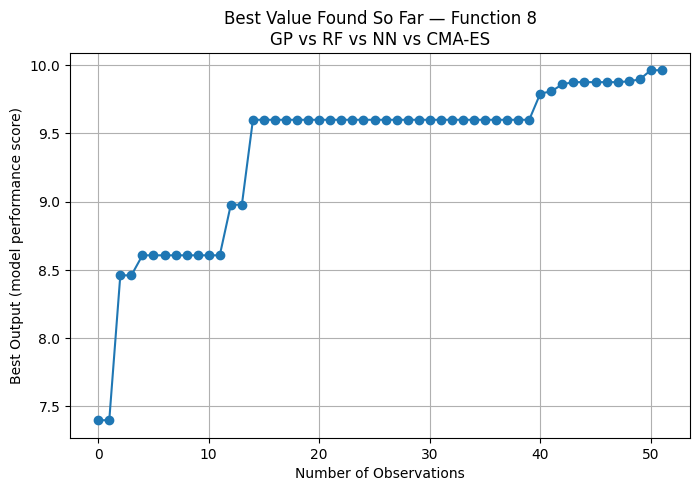

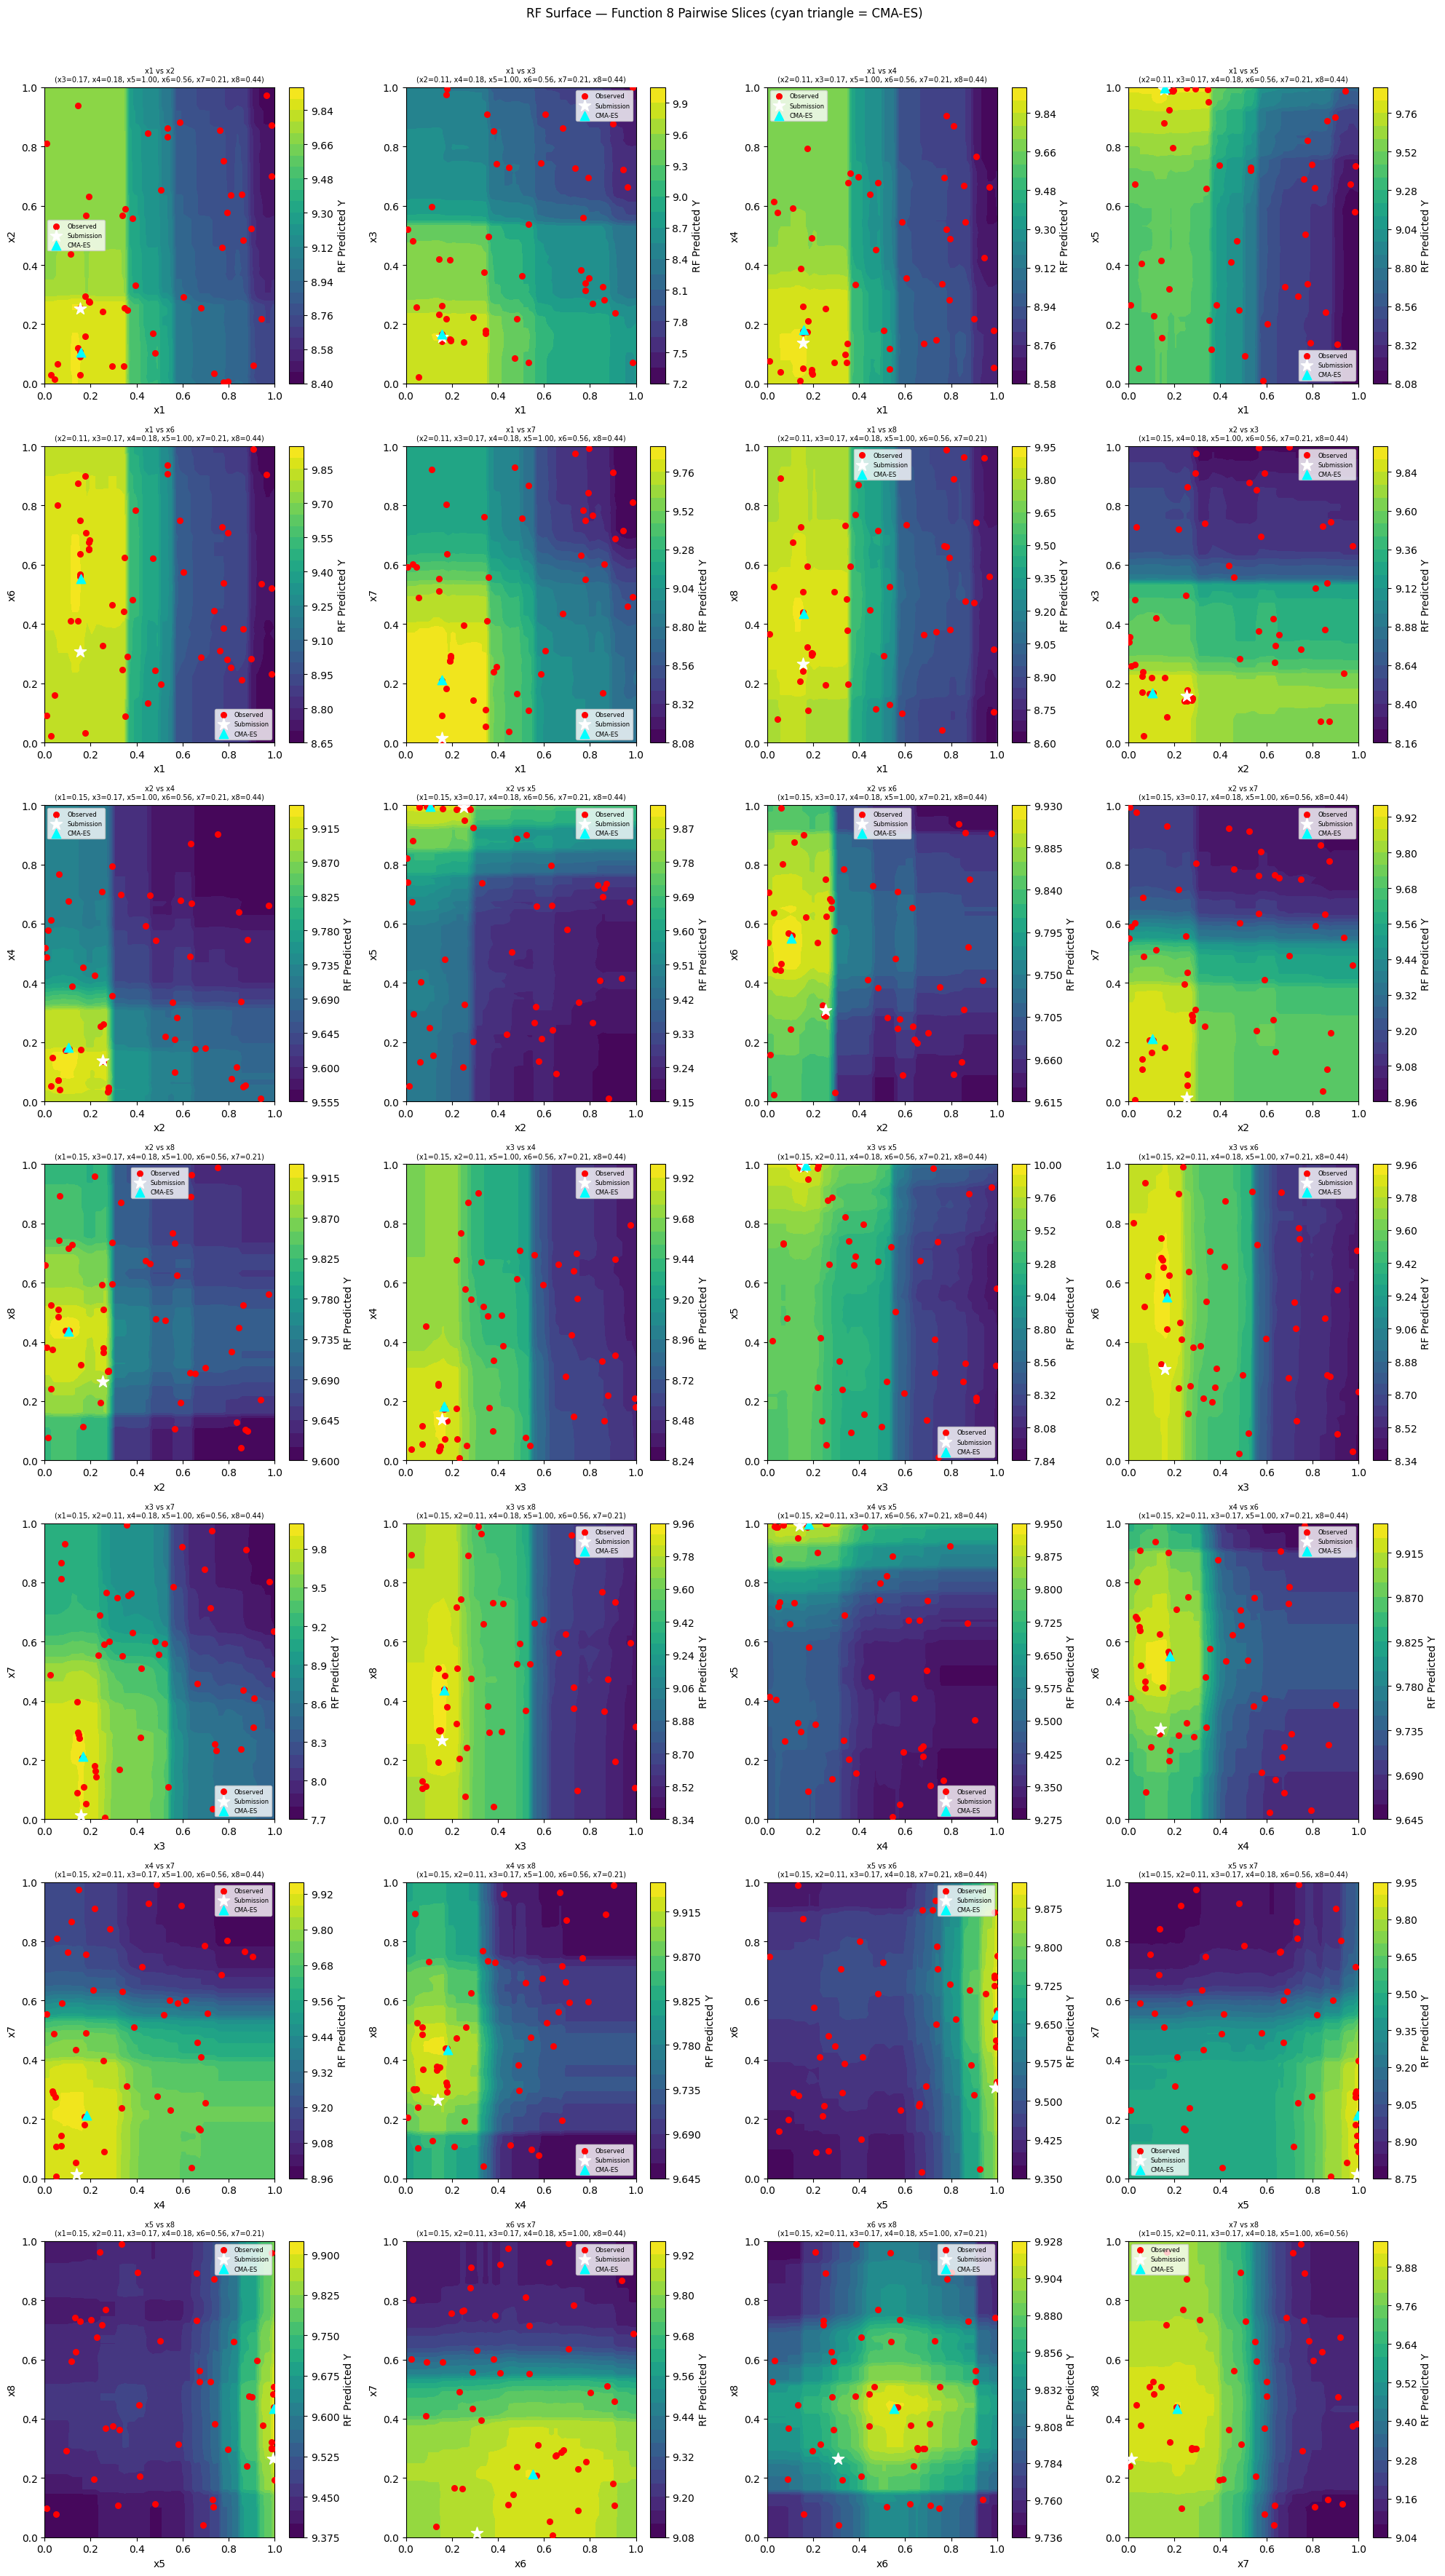


Top 5 real evaluated points:
  Y=9.9613 | X=0.1550-0.1075-0.1663-0.1778-0.9991-0.5594-0.2072-0.4385
  Y=9.9597 | X=0.1552-0.0916-0.1649-0.1726-0.9968-0.5675-0.2078-0.4391
  Y=9.8942 | X=0.1926-0.2784-0.1507-0.0463-0.9867-0.6509-0.2743-0.3020
  Y=9.8799 | X=0.1933-0.2777-0.1471-0.0372-0.9873-0.6763-0.2871-0.2995
  Y=9.8740 | X=0.1954-0.2737-0.1438-0.0328-0.9895-0.6841-0.2931-0.3003


In [5]:
# =====================================================
# FUNCTION 8 — 8D ML Hyperparameter Tuning
# Week 9: length_scale_bounds tightened (1e-3, 1e3)
# Week 9: plausibility check added to selection
# Week 9: Optuna CMA-ES added as 5th candidate
#         GP has been highly accurate (error 0.005)
#         CMA-ES exploits this with tight sigma0
# =====================================================
import warnings
import optuna
from sklearn.exceptions import ConvergenceWarning

optuna.logging.set_verbosity(optuna.logging.WARNING)

# =====================================================
# GP MODEL — two kernels as per func7 pattern week 7
# Week 9: kernel_main bounds tightened 1e8 → 1e3
#         to match kernel_loo and prevent bound issues
# Observation: GP prediction error was only 0.005
#              last week — model is well fitted
# =====================================================
kernel_main = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=np.ones(dim),
          length_scale_bounds=(1e-3, 1e3))
    + WhiteKernel(noise_level=1e-3,
                  noise_level_bounds=(1e-10, 1e-1))
)

kernel_loo = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=np.ones(dim),
          length_scale_bounds=(1e-3, 1e5))
    + WhiteKernel(noise_level=1e-3,
                  noise_level_bounds=(1e-10, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel_main,
    alpha=1e-5,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

# =====================================================
# RF SURROGATE — GridSearchCV tuning week 8
# =====================================================
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators':     [200, 500, 1000],
    'max_features':     ['sqrt', 'log2', 0.5],
    'min_samples_leaf': [1, 2, 3]
}

rf_tuner = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# =====================================================
# NN SURROGATE — larger architecture week 8
# =====================================================
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    max_iter=10000,
    random_state=42,
    alpha=0.001,
    early_stopping=True,
    validation_fraction=0.10,
    learning_rate_init=0.001
)

# =====================================================
# ACQUISITION FUNCTIONS
# =====================================================
def expected_improvement_gp(X_cands, gp,
                              Y_ref, xi=0.05):
    mean, std = gp.predict(X_cands, return_std=True)
    best_y = np.max(Y_ref)
    std    = np.maximum(std.reshape(-1), 1e-9)
    mean   = mean.reshape(-1)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei

def expected_improvement_rf(X_cands, rf,
                              Y_ref, xi=0.05):
    predictions = np.array([tree.predict(X_cands)
                             for tree in rf.estimators_])
    mean   = predictions.mean(axis=0)
    std    = np.maximum(predictions.std(axis=0), 1e-9)
    best_y = np.max(Y_ref)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei

def expected_improvement_nn(X_cands, nn,
                              Y_ref, xi=0.05):
    mean   = nn.predict(X_cands)
    std    = np.maximum(
        np.full_like(mean, np.std(Y_ref) * 0.1), 1e-9)
    best_y = np.max(Y_ref)
    Z      = (mean - best_y - xi) / std
    ei     = ((mean - best_y - xi) * norm.cdf(Z)
               + std * norm.pdf(Z))
    ei[std == 0] = 0
    return ei

# =====================================================
# FIT ALL SURROGATES
# =====================================================
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# GP
with warnings.catch_warnings():
    warnings.filterwarnings("ignore",
                            category=ConvergenceWarning)
    gp.fit(X_scaled, Y)

# RF — GridSearchCV tuning
print("Running GridSearchCV for RF...")
rf_tuner.fit(X_scaled, Y)
best_rf_params = rf_tuner.best_params_
print(f"Best RF parameters:")
print(f"  n_estimators:     {best_rf_params['n_estimators']}")
print(f"  max_features:     {best_rf_params['max_features']}")
print(f"  min_samples_leaf: {best_rf_params['min_samples_leaf']}")
print(f"  CV score (neg MSE): {rf_tuner.best_score_:.4f}")

rf = RandomForestRegressor(
    n_estimators=best_rf_params['n_estimators'],
    max_features=best_rf_params['max_features'],
    min_samples_leaf=best_rf_params['min_samples_leaf'],
    random_state=42,
    n_jobs=-1
)
rf.fit(X_scaled, Y)

# NN
nn.fit(X_scaled, Y)
print(f"NN trained for {nn.n_iter_} iterations")
print("\nAll surrogates fitted")

best_point = X[np.argmax(Y)]
print(f"Best real point: {best_point}")
print(f"Best real Y:     {np.max(Y):.6f}")

# Print GP kernel length scales
print("\nFitted kernel length scales:")
for i, ls in enumerate(gp.kernel_.k1.k2.length_scale):
    flag = " ← hitting bound" \
           if ls >= 999 or ls <= 0.002 else ""
    print(f"  x{i+1}: {ls:.4f}{flag}")

# =====================================================
# LOO CROSS VALIDATION
# =====================================================
from sklearn.model_selection import LeaveOneOut

loo        = LeaveOneOut()
gp_errors  = []
rf_errors  = []
nn_errors  = []

with warnings.catch_warnings():
    warnings.filterwarnings("ignore",
                            category=ConvergenceWarning)

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        scaler_cv = MinMaxScaler()
        X_train_s = scaler_cv.fit_transform(X_train)
        X_test_s  = scaler_cv.transform(X_test)

        gp_cv = GaussianProcessRegressor(
            kernel=kernel_loo, random_state=42,
            normalize_y=True, alpha=1e-5)
        gp_cv.fit(X_train_s, Y_train)
        gp_errors.append(
            (gp_cv.predict(X_test_s)[0] - Y_test[0])**2)

        rf_cv = RandomForestRegressor(
            n_estimators=best_rf_params['n_estimators'],
            max_features=best_rf_params['max_features'],
            min_samples_leaf=best_rf_params['min_samples_leaf'],
            random_state=42, n_jobs=-1)
        rf_cv.fit(X_train_s, Y_train)
        rf_errors.append(
            (rf_cv.predict(X_test_s)[0] - Y_test[0])**2)

        nn_cv = MLPRegressor(
            hidden_layer_sizes=(64, 32, 16),
            activation='relu', max_iter=10000,
            random_state=42, alpha=0.001,
            early_stopping=True,
            validation_fraction=0.10,
            learning_rate_init=0.001)
        nn_cv.fit(X_train_s, Y_train)
        nn_errors.append(
            (nn_cv.predict(X_test_s)[0] - Y_test[0])**2)

gp_rmse = np.sqrt(np.mean(gp_errors))
rf_rmse = np.sqrt(np.mean(rf_errors))
nn_rmse = np.sqrt(np.mean(nn_errors))

rmse_dict     = {"GP": gp_rmse,
                  "RF": rf_rmse,
                  "NN": nn_rmse}
primary_model = min(rmse_dict, key=rmse_dict.get)

print(f"\n=== LOO CROSS VALIDATION ===")
print(f"GP  LOO RMSE: {gp_rmse:.4f}")
print(f"RF  LOO RMSE: {rf_rmse:.4f}")
print(f"NN  LOO RMSE: {nn_rmse:.4f}")
print(f"Primary surrogate: {primary_model}")

# =====================================================
# GENERATE CANDIDATES
# =====================================================
np.random.seed(42)
n_candidates = 300000

sampler = qmc.LatinHypercube(d=dim, seed=42)
X_lhs   = sampler.random(int(n_candidates * 0.5))

X_lhs[:, 0] = X_lhs[:, 0] * 0.35          # x1: 0.0-0.35
X_lhs[:, 1] = X_lhs[:, 1] * 0.28          # x2: 0.0-0.28
X_lhs[:, 2] = X_lhs[:, 2] * 0.27          # x3: 0.0-0.27
X_lhs[:, 3] = X_lhs[:, 3] * 0.26          # x4: 0.0-0.26
X_lhs[:, 4] = X_lhs[:, 4] * 0.12 + 0.88  # x5: 0.88-1.0
X_lhs[:, 5] = X_lhs[:, 5] * 0.60 + 0.30  # x6: 0.30-0.90
X_lhs[:, 6] = X_lhs[:, 6] * 0.40          # x7: 0.0-0.40
X_lhs[:, 7] = X_lhs[:, 7] * 0.40 + 0.15  # x8: 0.15-0.55

n_local = n_candidates - len(X_lhs)
noise   = np.random.normal(0, 0.02,
                            size=(n_local, dim))
X_local = np.clip(best_point + noise,
                   0.0, 0.999999)

# Clip floors — prevent boundary saturation
X_local[:, 0] = np.clip(X_local[:, 0], 0.155, 0.999999)
X_local[:, 2] = np.clip(X_local[:, 2], 0.141, 0.999999)
X_lhs[:, 0]   = np.clip(X_lhs[:, 0],   0.155, 0.999999)
X_lhs[:, 2]   = np.clip(X_lhs[:, 2],   0.141, 0.999999)

X_candidates        = np.vstack([X_lhs, X_local])
X_candidates_scaled = scaler.transform(X_candidates)

# =====================================================
# SCORE WITH ALL THREE SURROGATES
# =====================================================
ei_gp = expected_improvement_gp(
    X_candidates_scaled, gp, Y, xi=0.05)
ei_rf = expected_improvement_rf(
    X_candidates_scaled, rf, Y, xi=0.01)
ei_nn = expected_improvement_nn(
    X_candidates_scaled, nn, Y, xi=0.05)

x_submit_gp = X_candidates[np.argmax(ei_gp)]
x_submit_rf = X_candidates[np.argmax(ei_rf)]
x_submit_nn = X_candidates[np.argmax(ei_nn)]

pred_gp = gp.predict(scaler.transform([x_submit_gp]))[0]
pred_rf = rf.predict(scaler.transform([x_submit_rf]))[0]
pred_nn = nn.predict(scaler.transform([x_submit_nn]))[0]

dist_gp = np.linalg.norm(x_submit_gp - best_point)
dist_rf = np.linalg.norm(x_submit_rf - best_point)
dist_nn = np.linalg.norm(x_submit_nn - best_point)

# =====================================================
# RF QUALITY FILTERED
# =====================================================
quality_threshold = np.percentile(Y, 60)
quality_mask      = Y >= quality_threshold
X_quality         = X_scaled[quality_mask]
Y_quality         = Y[quality_mask]

print(f"\nRF quality filter: "
      f"{quality_mask.sum()} points "
      f"at Y >= {quality_threshold:.4f}")

rf_quality = RandomForestRegressor(
    n_estimators=best_rf_params['n_estimators'],
    max_features=best_rf_params['max_features'],
    min_samples_leaf=best_rf_params['min_samples_leaf'],
    random_state=42, n_jobs=-1
)
rf_quality.fit(X_quality, Y_quality)

ei_rfq       = expected_improvement_rf(
    X_candidates_scaled, rf_quality,
    Y_quality, xi=0.01)
x_submit_rfq = X_candidates[np.argmax(ei_rfq)]
pred_rfq     = rf_quality.predict(
    scaler.transform([x_submit_rfq]))[0]
dist_rfq     = np.linalg.norm(
    x_submit_rfq - best_point)

# =====================================================
# OPTUNA CMA-ES — week 9 addition
# GP has been highly accurate on F8 (error 0.005)
# CMA-ES exploits confirmed best region with tight
# sigma0 — ideal for exploitation phase
# 8D with confirmed ranges maps cleanly to bounds dict
# =====================================================
BOUNDS_F8 = {
    "x1": (0.155, 0.350),
    "x2": (0.029, 0.280),
    "x3": (0.141, 0.263),
    "x4": (0.033, 0.260),
    "x5": (0.879, 0.999),
    "x6": (0.300, 0.900),
    "x7": (0.000, 0.400),
    "x8": (0.150, 0.550),
}

def build_warm_study(X_obs, Y_obs, bounds, sampler,
                     direction="maximize"):
    """Load existing observations into Optuna study."""
    study = optuna.create_study(direction=direction,
                                sampler=sampler)
    distributions = {
        name: optuna.distributions.FloatDistribution(
            lo, hi)
        for name, (lo, hi) in bounds.items()
    }
    for x_row, y_val in zip(X_obs, Y_obs):
        params = {
            name: float(np.clip(x_row[i], lo, hi))
            for i, (name, (lo, hi)) in enumerate(
                bounds.items())
        }
        study.add_trial(optuna.trial.create_trial(
            params=params,
            distributions=distributions,
            value=float(y_val)
        ))
    return study

# sigma0 = min_range / 6 — tight exploitation
sigma0_f8 = min(
    hi - lo for lo, hi in BOUNDS_F8.values()) / 6.0
sigma0_f8 = max(sigma0_f8, 0.003)

cmaes_sampler = optuna.samplers.CmaEsSampler(
    x0={
        name: float(np.clip(best_point[i], lo, hi))
        for i, (name, (lo, hi)) in enumerate(
            BOUNDS_F8.items())
    },
    sigma0=sigma0_f8,
    seed=42
)

study_cmaes = build_warm_study(
    X, Y, BOUNDS_F8, cmaes_sampler)
trial_cmaes = study_cmaes.ask()
x_cmaes = np.array([
    trial_cmaes.suggest_float(name, lo, hi)
    for name, (lo, hi) in BOUNDS_F8.items()
])

# Score CMA-ES suggestion through GP
pred_cmaes = gp.predict(
    scaler.transform([x_cmaes]))[0]
dist_cmaes = np.linalg.norm(x_cmaes - best_point)

# =====================================================
# FULL COMPARISON — 5 candidates
# =====================================================
print("\n" + "="*55)
print("5 SURROGATE COMPARISON — Function 8")
print("="*55)

models = {
    "GP":         (x_submit_gp,  pred_gp,    dist_gp),
    "RF":         (x_submit_rf,  pred_rf,    dist_rf),
    "RF-quality": (x_submit_rfq, pred_rfq,   dist_rfq),
    "NN":         (x_submit_nn,  pred_nn,    dist_nn),
    "CMA-ES":     (x_cmaes,      pred_cmaes, dist_cmaes),
}

for name, (x_sub, pred, dist) in models.items():
    if name == "GP":
        loo_label = f" (LOO={gp_rmse:.3f})"
    elif name in ("RF", "RF-quality"):
        loo_label = f" (LOO={rf_rmse:.3f})"
    elif name == "NN":
        loo_label = f" (LOO={nn_rmse:.3f})"
    else:
        loo_label = f" (sigma0={sigma0_f8:.4f})"
    print(f"\n--- {name}{loo_label} ---")
    print(f"  Suggestion:         "
          f"{'-'.join([f'{x:.6f}' for x in x_sub])}")
    print(f"  GP predicted Y:     {pred:.6f}")
    print(f"  Distance from best: {dist:.6f}")
    print(f"  x1={x_sub[0]:.4f} x2={x_sub[1]:.4f} "
          f"x3={x_sub[2]:.4f} x4={x_sub[3]:.4f} "
          f"x5={x_sub[4]:.4f}")

# Confidence — pairwise distance across all 5
suggestions = np.array([x_submit_gp, x_submit_rf,
                         x_submit_rfq, x_submit_nn,
                         x_cmaes])
pairwise    = cdist(suggestions, suggestions)
mean_dist   = pairwise[
    np.triu_indices(5, k=1)].mean()

print(f"\nMean distance between suggestions: "
      f"{mean_dist:.4f}")
if mean_dist < 0.10:
    print("HIGH CONFIDENCE — all models agree")
    confidence = "HIGH"
elif mean_dist < 0.30:
    print("MODERATE CONFIDENCE — broadly agree")
    confidence = "MODERATE"
else:
    print("LOW CONFIDENCE — models disagree")
    confidence = "LOW"

# =====================================================
# RANGE VALIDATION
# =====================================================
confirmed_ranges = {
    'x1': (0.155, 0.350),
    'x2': (0.029, 0.280),
    'x3': (0.141, 0.263),
    'x4': (0.033, 0.260),
    'x5': (0.879, 0.999)
}

def passes_range(x_sub):
    for dim_name, (low, high) in confirmed_ranges.items():
        idx = int(dim_name[1]) - 1
        if not (low <= x_sub[idx] <= high):
            return False
    return True

# =====================================================
# SUBMISSION SELECTION
# LOO primary wins if eligible and plausible
# CMA-ES competes on equal terms with GP/RF/NN
#
# PLAUSIBILITY CHECK — added week 9
# Best real Y = 9.874, floor = 70%, ceil = 130%
# GP has been very accurate — use GP pred for all
# =====================================================
threshold = 0.50

best_real_y        = np.max(Y)
plausibility_floor = 0.70 * best_real_y
plausibility_ceil  = 1.30 * best_real_y

def plausible(pred):
    """GP-predicted Y within plausibility bounds."""
    return plausibility_floor <= pred <= plausibility_ceil

print(f"\n{'='*55}")
print("SUBMISSION SELECTION")
print(f"{'='*55}")
print(f"Plausibility bounds: "
      f"[{plausibility_floor:.4f}, "
      f"{plausibility_ceil:.4f}]")

candidates_final = []
for name, (x_sub, pred, dist) in models.items():
    in_range = passes_range(x_sub)
    eligible = (dist <= threshold) and in_range
    status   = "eligible" if eligible else "excluded"
    reason   = ""
    if dist > threshold:
        reason = f"dist={dist:.4f} > {threshold}"
    elif not in_range:
        reason = "outside confirmed range"
    print(f"  {name}: {status}"
          f"{' — ' + reason if reason else ''} | "
          f"pred={pred:.4f} | "
          f"plausible={plausible(pred)}")
    if eligible:
        candidates_final.append(
            (name, x_sub, pred, dist))

if len(candidates_final) == 0:
    print("No models eligible — using GP")
    x_final      = x_submit_gp
    chosen_model = "GP (fallback)"
else:
    # Step 1 — primary LOO model among eligible
    primary_eligible = [
        c for c in candidates_final
        if primary_model.upper() in c[0].upper()]

    # Step 2 — filter to plausible only
    primary_plausible = [
        c for c in primary_eligible
        if plausible(c[2])]

    if primary_plausible:
        best_eligible = max(primary_plausible,
                            key=lambda t: t[2])
        x_final      = best_eligible[1]
        chosen_model = (f"{best_eligible[0]} "
                        f"(LOO primary)")
    else:
        # Primary failed plausibility — override
        # Pick highest GP-predicted plausible candidate
        all_plausible = [
            c for c in candidates_final
            if plausible(c[2])]
        if all_plausible:
            best_eligible = max(all_plausible,
                                key=lambda t: t[2])
            x_final      = best_eligible[1]
            chosen_model = (f"{best_eligible[0]} "
                            f"(plausibility override)")
            print(f"\n⚠ Primary model failed "
                  f"plausibility — "
                  f"overriding to {best_eligible[0]}")
        else:
            best_eligible = max(candidates_final,
                                key=lambda t: t[2])
            x_final      = best_eligible[1]
            chosen_model = (f"{best_eligible[0]} "
                            f"(all implausible — "
                            f"highest pred)")

submission = "-".join([f"{x:.6f}" for x in x_final])
dist_final = np.linalg.norm(x_final - best_point)

# Range validation for chosen model
print(f"\n--- Range validation ({chosen_model}) ---")
for dim_name, (low, high) in confirmed_ranges.items():
    idx = int(dim_name[1]) - 1
    val = x_final[idx]
    ok  = low <= val <= high
    print(f"  {dim_name}={val:.4f} "
          f"[{low:.3f}-{high:.3f}] "
          f"{'yes' if ok else 'no'}")

print(f"\n===== FINAL SUBMISSION ({chosen_model}) =====")
print(submission)
print(f"\nGP          predicted Y: {pred_gp:.6f}")
print(f"RF          predicted Y: {pred_rf:.6f}")
print(f"RF-quality  predicted Y: {pred_rfq:.6f}")
print(f"NN          predicted Y: {pred_nn:.6f}")
print(f"CMA-ES      predicted Y: {pred_cmaes:.6f}")
print(f"Best real Y:             {np.max(Y):.6f}")
print(f"Distance from best:      {dist_final:.6f}")
print(f"Confidence:              {confidence}")
print(f"Plausibility bounds:     "
      f"[{plausibility_floor:.4f}, "
      f"{plausibility_ceil:.4f}]")
print(f"CMA-ES sigma0:           {sigma0_f8:.4f}")
print(f"Primary (LOO):           {primary_model} "
      f"(GP={gp_rmse:.3f}, RF={rf_rmse:.3f}, "
      f"NN={nn_rmse:.3f})")
print(f"Best RF params:          {best_rf_params}")
print(f"Dataset size:            {len(Y)}")

# =====================================================
# PLOT 1 — optimisation progress
# =====================================================
best_values = np.maximum.accumulate(Y)
plt.figure(figsize=(8, 5))
plt.plot(best_values, marker='o')
plt.title("Best Value Found So Far — Function 8\n"
          "GP vs RF vs NN vs CMA-ES")
plt.xlabel("Number of Observations")
plt.ylabel("Best Output (model performance score)")
plt.grid(True)
plt.show()

# =====================================================
# PLOT 2 — pairwise slices (RF surface)
# =====================================================
from itertools import combinations

dim_pairs = list(combinations(range(dim), 2))
n_plots   = len(dim_pairs)
n_cols    = 4
n_rows    = (n_plots + n_cols - 1) // n_cols
labels    = ['x1', 'x2', 'x3', 'x4',
             'x5', 'x6', 'x7', 'x8']

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(20, n_rows * 5))
axes = axes.ravel()

for ax, (xi_idx, xj_idx) in zip(axes, dim_pairs):
    xi_range = np.linspace(0, 1, 50)
    xj_range = np.linspace(0, 1, 50)
    xxi, xxj = np.meshgrid(xi_range, xj_range)

    grid = np.tile(best_point, (xxi.size, 1))
    grid[:, xi_idx] = xxi.ravel()
    grid[:, xj_idx] = xxj.ravel()

    grid_scaled = scaler.transform(grid)
    mean_pred   = rf.predict(grid_scaled)

    cf = ax.contourf(xxi, xxj,
                     mean_pred.reshape(xxi.shape),
                     levels=25, cmap="viridis")
    plt.colorbar(cf, ax=ax, label="RF Predicted Y")
    ax.scatter(X[:, xi_idx], X[:, xj_idx],
               c="red", s=30, zorder=5,
               label="Observed")
    ax.scatter(x_final[xi_idx], x_final[xj_idx],
               c="white", s=150, marker="*",
               zorder=6, label="Submission")
    # Show CMA-ES suggestion for comparison
    ax.scatter(x_cmaes[xi_idx], x_cmaes[xj_idx],
               c="cyan", s=80, marker="^",
               zorder=6, label="CMA-ES")
    ax.set_xlabel(labels[xi_idx])
    ax.set_ylabel(labels[xj_idx])

    fixed_dims = [l for i, l in enumerate(labels)
                  if i != xi_idx and i != xj_idx]
    fixed_vals = [f"{best_point[i]:.2f}"
                  for i in range(dim)
                  if i != xi_idx and i != xj_idx]
    fixed_str  = ", ".join([f"{d}={v}"
                             for d, v
                             in zip(fixed_dims,
                                    fixed_vals)])
    ax.set_title(f"{labels[xi_idx]} vs "
                 f"{labels[xj_idx]}\n"
                 f"({fixed_str})", fontsize=7)
    ax.legend(fontsize=6)

for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle("RF Surface — Function 8 Pairwise Slices"
             " (cyan triangle = CMA-ES)",
             y=1.01)
plt.tight_layout()
plt.show()

# =====================================================
# TOP 5 REAL RESULTS
# =====================================================
top_indices = np.argsort(Y)[-5:][::-1]
print("\nTop 5 real evaluated points:")
for idx in top_indices:
    vals = "-".join([f"{v:.4f}" for v in X[idx]])
    print(f"  Y={Y[idx]:.4f} | X={vals}")

In [9]:
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Y values:", Y[-5:]) 

X shape: (47, 8)
Y shape: (47,)
Y values: [9.85834446 9.87402106 9.82092223 9.78438228 9.86353659]
